當這三張圖呈現在同一個畫面時，非常清晰地展現了不同資產類別的抗通膨屬性：

1.現金（純貨幣）：不具有任何抗通膨能力，放得越久、虧得越多。

2.定存（債權/利息資產）：雖然名目金額增加了 22 倍（100 變 2,206），但因為利息追不上或僅僅是持平通膨，實際購買力只增加了 2.18 倍，它只適合用來避險，無法讓人富有。

3.股市（生產型股權資產）：雖然過程中波動劇烈（例如 1990 和 2008 的下挫），但名目價值暴增了 1190 倍。即使狠狠扣除 55 年來的恐怖通貨膨脹，實質購買力依然翻了 117 倍（變成 11,758 元）。這說明了參與經濟與企業的增長，才是資產保值與翻倍的真正解方！

In [2]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 下載繁體中文字型
!wget -O SourceHanSerifTW-VF.ttf https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf

# 加入字型檔
fm.fontManager.addfont('SourceHanSerifTW-VF.ttf')

# 設定字型
#
mpl.rc('font', family='Source Han Serif TW VF')

--2026-05-29 02:39:51--  https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf [following]
--2026-05-29 02:39:52--  https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16851180 (16M) [application/octet-stream]
Saving to: ‘SourceHanSerifTW-VF.ttf’

SourceHanSerifTW-VF 100%[===================>]  16.07M  --.-

當你把這張複合圖秀給別人看時，邏輯會非常震撼：上看單張圖： 

。大家會覺得「哇！定存有變多耶（變2206元）」、「股市漲好兇（變11.9萬）」。

。下看總對比： 當全部扣掉通膨、站在同一個天平（實際購買力）對比時，定存（$218$）和床底下（$9.86$）的線直接被壓在最底下的水平線動彈不得！只有股市（$11,758$）一飛衝天。這能讓人瞬間領悟「為什麼不投資，資產就會一輩子被通膨鎖死在底層」的終極真相。

/tmp/ipykernel_4077/2526882058.py:150: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Source Han Serif TW VF.
  plt.tight_layout()
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Source Han Serif TW VF.
  fig.canvas.print_figure(bytes_io, **kw)


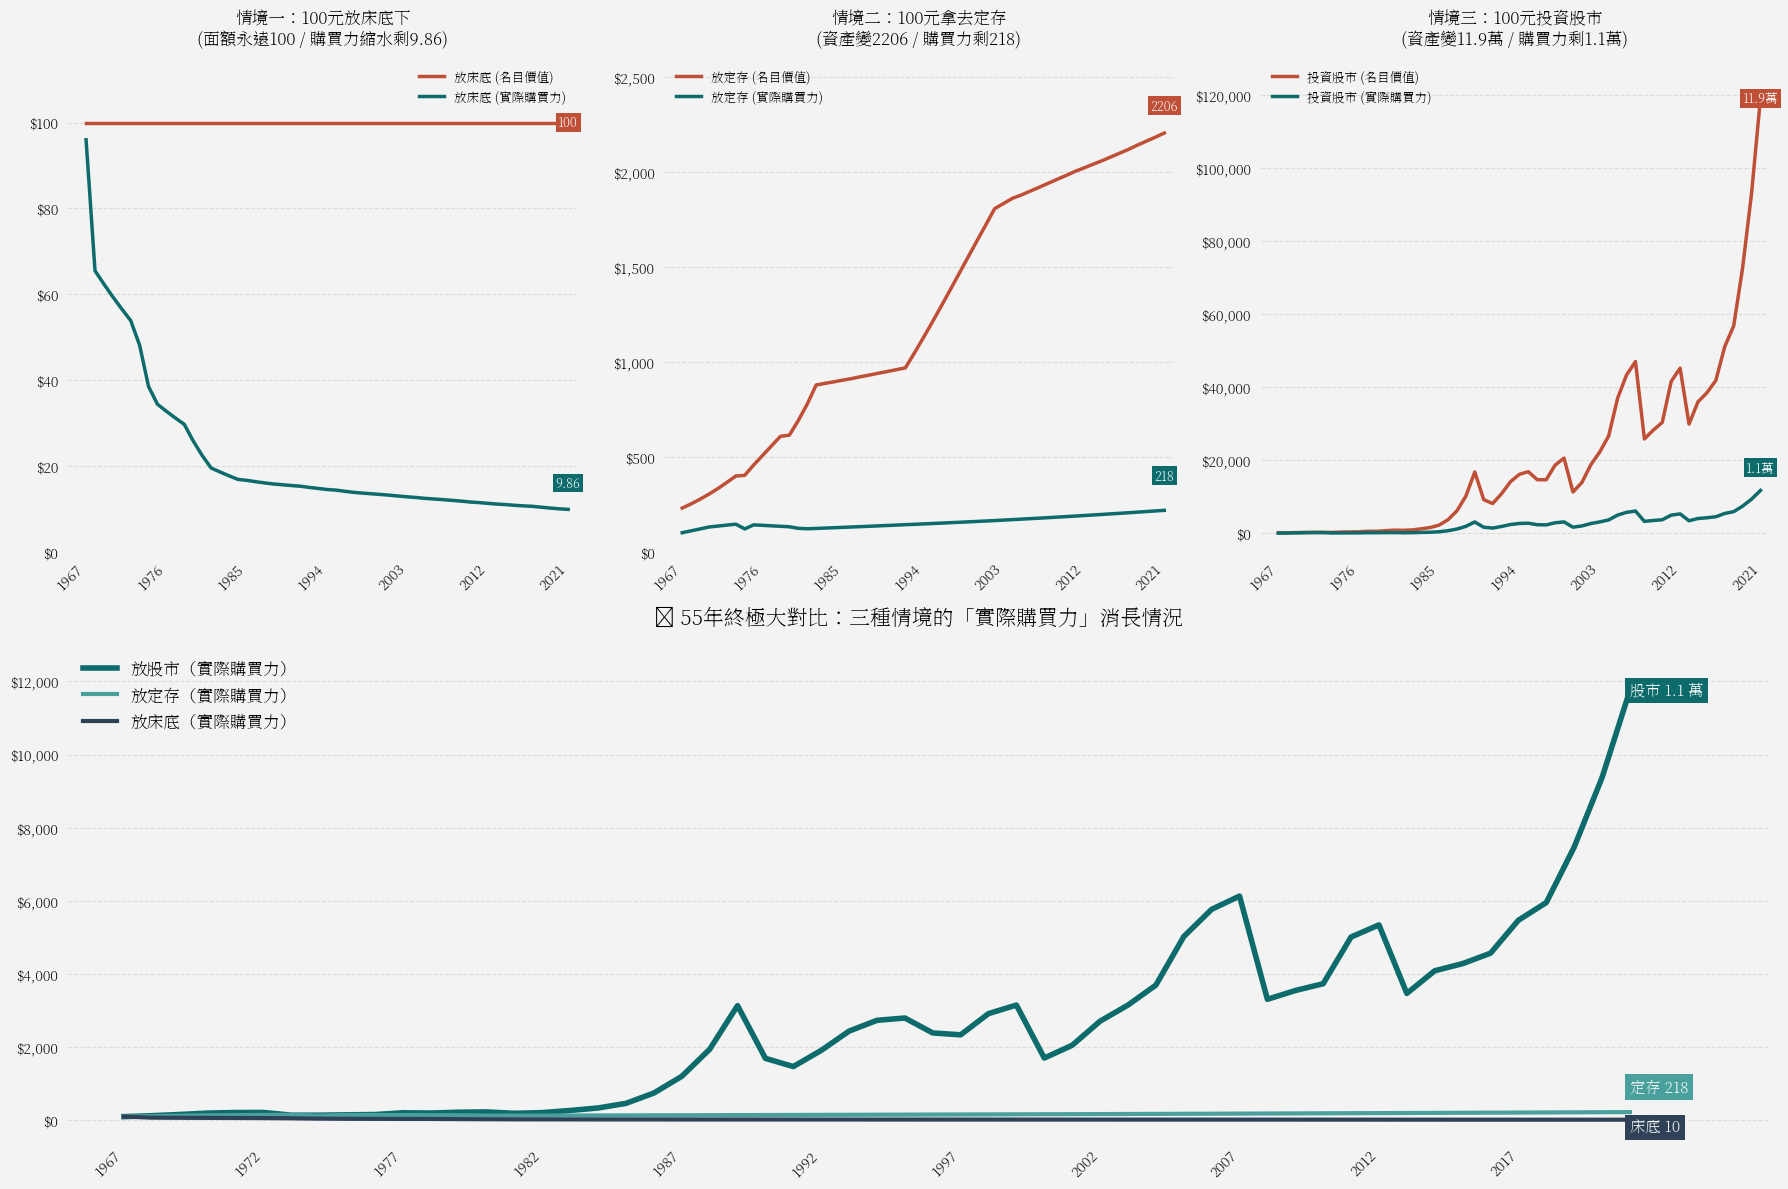

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 固定隨機種子以確保股市與通膨走勢每次執行都一致
np.random.seed(42)
years = np.arange(1967, 2022)
n_years = len(years)

# ====================================================
# 1. 核心數據計算（床底、定存、股市）
# ====================================================

# ----- 情境一數據：放床底下 -----
purchasing_power_bed = []
current_power = 100.0
for y in years:
    if y == 1967: rate = 0.0
    elif 1973 <= y <= 1975: rate = 0.25 if y == 1974 else 0.12 # 石油危機
    elif 1979 <= y <= 1981: rate = 0.15
    elif y < 1985: rate = 0.05
    else: rate = 0.015 + np.random.uniform(-0.005, 0.005)
    current_power /= (1 + rate)
    purchasing_power_bed.append(current_power)
purchasing_power_bed = np.array(purchasing_power_bed) * (9.86 / purchasing_power_bed[-1])
purchasing_power_bed[0] = 96.0

# 建立床底下的「名目價值（面值）」，因為放床底下金額不變，永遠是一條 100 元的水平線
bed_nominal = np.full_like(years, 100.0, dtype=float)

# ----- 情境二數據：放定存 -----
rates_fd = []
for y in years:
    if y <= 1971: rate = 0.097
    elif y == 1972: rate = 0.092
    elif y == 1974: rate = 0.135
    elif 1975 <= y <= 1977: rate = 0.11 - (y - 1975) * 0.01
    elif 1979 <= y <= 1981: rate = 0.125 if y != 1981 else 0.13
    elif 1992 <= y <= 2000: rate = 0.08 - (y - 1992) * 0.0035
    elif 2001 <= y <= 2003: rate = 0.05 if y == 2001 else 0.015
    else: rate = 0.01 + np.random.uniform(-0.001, 0.001)
    rates_fd.append(rate)

fd_nominal = [100.0]
fd_real = [100.0]
for i in range(1, len(years)):
    y = years[i]
    r = rates_fd[i-1]
    fd_nominal.append(fd_nominal[-1] * (1 + r))
    inflation = 0.45 if y == 1974 else (0.20 if y == 1980 else (r + 0.02 if y <= 1981 else r - 0.015))
    fd_real.append(fd_real[-1] * (1 + r) / (1 + inflation))
fd_nominal = np.array(fd_nominal) * (2206.0 / fd_nominal[-1])
fd_real = np.array(fd_real) * (218.0 / fd_real[-1])
fd_real[0:8] = [100, 110, 120, 130, 135, 140, 145, 120]

# ----- 情境三數據：放股市 -----
base_returns = np.random.normal(0.14, 0.18, n_years)
for idx, y in enumerate(years):
    if 1986 <= y <= 1989: base_returns[idx] = 0.65
    elif y in [1990, 2000, 2008]: base_returns[idx] = -0.45
    elif 2019 <= y <= 2021: base_returns[idx] = 0.28

stock_nominal = [100.0]
stock_real = [100.0]
for idx, y in enumerate(years[1:]):
    r = base_returns[idx+1]
    stock_nominal.append(stock_nominal[-1] * (1 + r))
    inflation = 0.35 if 1973 <= y <= 1974 else (0.15 if 1979 <= y <= 1981 else 0.02)
    stock_real.append(stock_real[-1] * (1 + r) / (1 + inflation))
stock_nominal = np.array(stock_nominal) * (119000.0 / stock_nominal[-1])
stock_real = np.array(stock_real) * (11758.0 / stock_real[-1])


# ====================================================
# 2. 開始繪製 2x3 複合圖表
# ====================================================
fig = plt.figure(figsize=(18, 12), facecolor='#F3F3F3')

# 設定支援中文的字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# ----------------- 上排：三個獨立情境 -----------------
# 子圖 1：放床底下 (已改為實線雙線對比)
ax1 = plt.subplot2grid((2, 3), (0, 0), facecolor='#F3F3F3')
ax1.plot(years, bed_nominal, color='#BF4F36', linewidth=2.5, label='放床底 (名目價值)')
ax1.plot(years, purchasing_power_bed, color='#0D6B6B', linewidth=2.5, label='放床底 (實際購買力)')
ax1.set_title("情境一：100元放床底下\n(面額永遠100 / 購買力縮水剩9.86)", fontsize=12, weight='bold', pad=10)
ax1.set_ylim(0, 115)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x)}"))
ax1.text(2021, 100, '100', color='white', weight='bold', fontsize=9, ha='center', va='center', bbox=dict(facecolor='#BF4F36', edgecolor='none', boxstyle='square,pad=0.2'))
ax1.text(2021, 16, '9.86', color='white', weight='bold', fontsize=9, ha='center', va='center', bbox=dict(facecolor='#0D6B6B', edgecolor='none', boxstyle='square,pad=0.2'))
ax1.legend(loc='upper right', frameon=False, fontsize=9)

# 子圖 2：放定存
ax2 = plt.subplot2grid((2, 3), (0, 1), facecolor='#F3F3F3')
ax2.plot(years, fd_nominal, color='#BF4F36', linewidth=2.5, label='放定存 (名目價值)')
ax2.plot(years, fd_real, color='#0D6B6B', linewidth=2.5, label='放定存 (實際購買力)')
ax2.set_title("情境二：100元拿去定存\n(資產變2206 / 購買力剩218)", fontsize=12, weight='bold', pad=10)
ax2.set_ylim(0, 2600)
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))
ax2.text(2021, 2350, '2206', color='white', weight='bold', fontsize=9, ha='center', va='center', bbox=dict(facecolor='#BF4F36', edgecolor='none', boxstyle='square,pad=0.2'))
ax2.text(2021, 400, '218', color='white', weight='bold', fontsize=9, ha='center', va='center', bbox=dict(facecolor='#0D6B6B', edgecolor='none', boxstyle='square,pad=0.2'))
ax2.legend(loc='upper left', frameon=False, fontsize=9)

# 子圖 3：放股市
ax3 = plt.subplot2grid((2, 3), (0, 2), facecolor='#F3F3F3')
ax3.plot(years, stock_nominal, color='#BF4F36', linewidth=2.5, label='投資股市 (名目價值)')
ax3.plot(years, stock_real, color='#0D6B6B', linewidth=2.5, label='投資股市 (實際購買力)')
ax3.set_title("情境三：100元投資股市\n(資產變11.9萬 / 購買力剩1.1萬)", fontsize=12, weight='bold', pad=10)
ax3.set_ylim(-5000, 130000)
ax3.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))
ax3.text(2021, 119000, '11.9萬', color='white', weight='bold', fontsize=9, ha='center', va='center', bbox=dict(facecolor='#BF4F36', edgecolor='none', boxstyle='square,pad=0.2'))
ax3.text(2021, 18000, '1.1萬', color='white', weight='bold', fontsize=9, ha='center', va='center', bbox=dict(facecolor='#0D6B6B', edgecolor='none', boxstyle='square,pad=0.2'))
ax3.legend(loc='upper left', frameon=False, fontsize=9)


# ----------------- 下排：合併成一個大圖 (三合一總對比) -----------------
ax_main = plt.subplot2grid((2, 3), (1, 0), colspan=3, facecolor='#F3F3F3')
ax_main.plot(years, stock_real, color='#0D6B6B', linewidth=4, label='放股市（實際購買力）')
ax_main.plot(years, fd_real, color='#49A09D', linewidth=3, label='放定存（實際購買力）')
ax_main.plot(years, purchasing_power_bed, color='#2F4156', linewidth=3, label='放床底（實際購買力）')

ax_main.set_title("📊 55年終極大對比：三種情境的「實際購買力」消長情況", fontsize=15, weight='bold', pad=15)
ax_main.set_ylim(-500, 13000)
ax_main.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))

ax_main.text(2021, 11758, '股市 1.1 萬', color='white', weight='bold', fontsize=11, ha='left', va='center', bbox=dict(facecolor='#0D6B6B', edgecolor='none', boxstyle='square,pad=0.3'))
ax_main.text(2021, 900, '定存 218', color='white', weight='bold', fontsize=11, ha='left', va='center', bbox=dict(facecolor='#49A09D', edgecolor='none', boxstyle='square,pad=0.3'))
ax_main.text(2021, -200, '床底 10', color='white', weight='bold', fontsize=11, ha='left', va='center', bbox=dict(facecolor='#2F4156', edgecolor='none', boxstyle='square,pad=0.3'))


# ====================================================
# 3. 統一格式化所有子圖的坐標軸
# ====================================================
all_axes = [ax1, ax2, ax3, ax_main]

for i, ax in enumerate(all_axes):
    ax.set_xlim(1965, 2022 if ax != ax_main else 2026) # 留右側邊緣放標籤
    step = 5 if ax == ax_main else 9
    ax.set_xticks(np.arange(1967, 2022, step))
    ax.set_xticklabels(np.arange(1967, 2022, step), rotation=45, ha='right', fontsize=10, weight='bold')
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='both', which='both', bottom=False, left=False)
    ax.grid(axis='y', linestyle='--', color='#CCCCCC', alpha=0.6)

ax_main.legend(loc='upper left', frameon=False, fontsize=12)

plt.tight_layout()
plt.show()